# **3. House Price Prediction**

**Objective**: Predict the price of a house based on features such as size, location, and number
of bedrooms.<br><br>


**Dataset**: Boston Housing dataset or any basic housing dataset with numeric features.<br>
**Steps**:<br>
o Load the dataset and explore data distributions.<br>
o Handle missing data and preprocess inputs (normalization).v
o Split into train/test sets.<br>
o Train a regression model (Linear Regression is classic for beginners).<br>
o Evaluate predictions using metrics like Mean Squared Error (MSE).<br>
 Skills gained: Handling tabular data, regression, feature engineering, basic metrics.<br>

## **Load the datasets and import the libraries**

In [121]:
from pandas import read_csv as rc
import pandas as pd
import numpy as np

In [122]:
pd.set_option('display.max_columns', None)

### **Loading the dataset from kaggle**

In [123]:
df=rc('dataset/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## **Data Statistics**

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [125]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [126]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

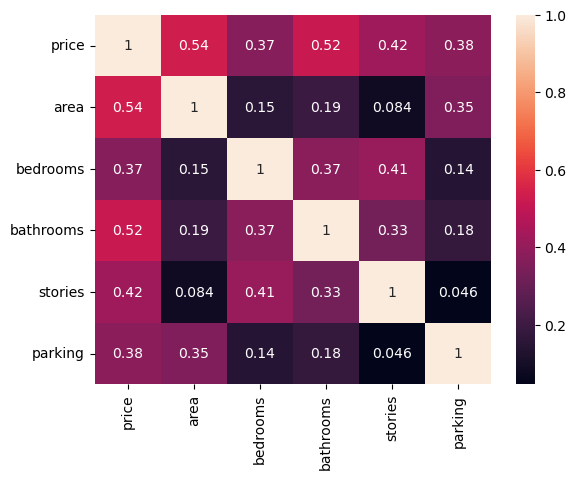

In [128]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: ylabel='price'>

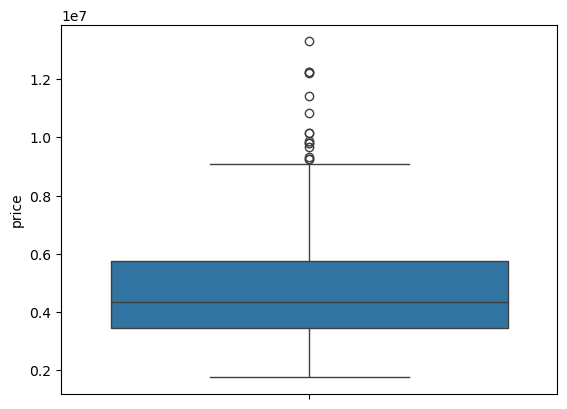

In [129]:
sns.boxplot(df['price'])

In [130]:
iqr = df['area'].quantile(0.75) - df['area'].quantile(0.25)
r1=df['area'].quantile(0.25) - 1.5 * iqr
r2 = df['area'].quantile(0.75) + 1.5 * iqr
df[(df['area'] < r1) | (df['area'] > r2)].head(20)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
56,7343000,11440,4,1,2,yes,no,yes,no,no,1,yes,semi-furnished
64,7000000,11175,3,1,1,yes,no,yes,no,yes,1,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
69,6790000,12090,4,2,2,yes,no,no,no,no,2,yes,furnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
129,5873000,11460,3,1,3,yes,no,no,no,no,2,yes,semi-furnished
186,5110000,11410,2,1,2,yes,no,no,no,no,0,yes,furnished
191,5040000,10700,3,1,2,yes,yes,yes,no,no,0,no,semi-furnished


In [131]:
df[(df['area'] > (df['area'].mean()+ 3*df['area'].std()))].head(20)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
10,9800000,13200,3,1,2,yes,no,yes,no,yes,2,yes,furnished
66,6930000,13200,2,1,1,yes,no,yes,yes,no,1,no,furnished
69,6790000,12090,4,2,2,yes,no,no,no,no,2,yes,furnished
125,5943000,15600,3,1,1,yes,no,no,no,yes,2,no,semi-furnished
211,4900000,12900,3,1,1,yes,no,no,no,no,2,no,furnished
403,3500000,12944,3,1,1,yes,no,no,no,no,0,no,unfurnished


<Axes: xlabel='furnishingstatus', ylabel='price'>

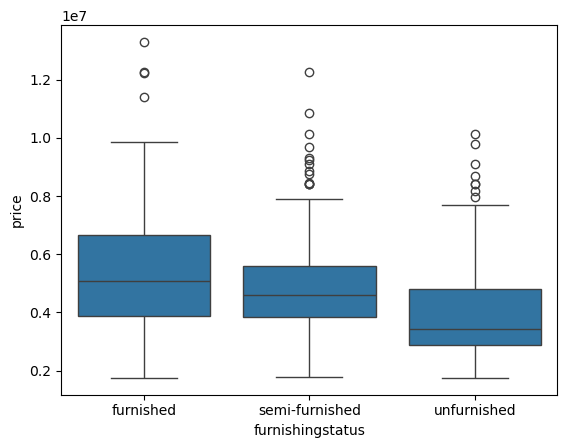

In [132]:
sns.boxplot(data=df,x='furnishingstatus',y='price')

<Axes: xlabel='area', ylabel='price'>

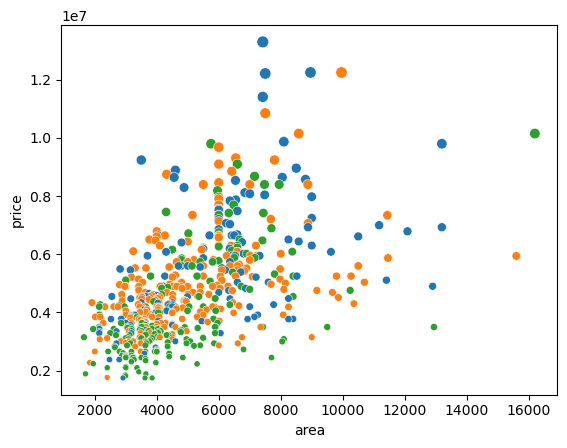

In [133]:
sns.scatterplot(y='price',x='area',data = df,hue='furnishingstatus',size='price',legend=False)

<Axes: xlabel='furnishingstatus'>

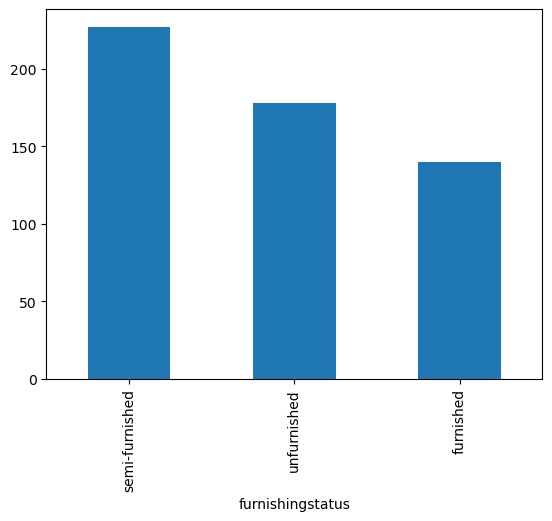

In [134]:
df['furnishingstatus'].value_counts().plot(kind='bar')

<Axes: xlabel='stories', ylabel='price'>

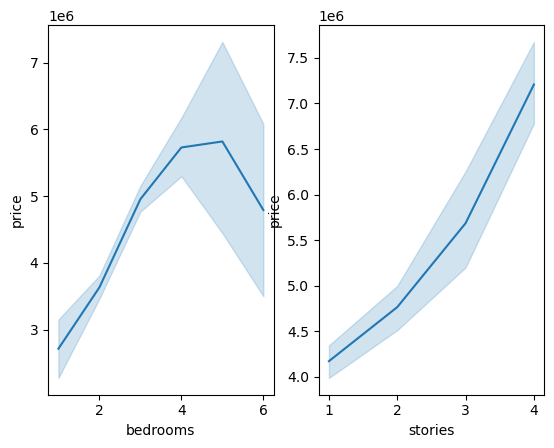

In [135]:
plt.subplot(1,2,1)
sns.lineplot(data=df,x='bedrooms',y='price')
plt.subplot(1,2,2)
sns.lineplot(data=df,x='stories',y='price')

In [136]:
df.sample()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
511,2520000,3180,3,1,1,no,no,no,no,no,0,no,unfurnished


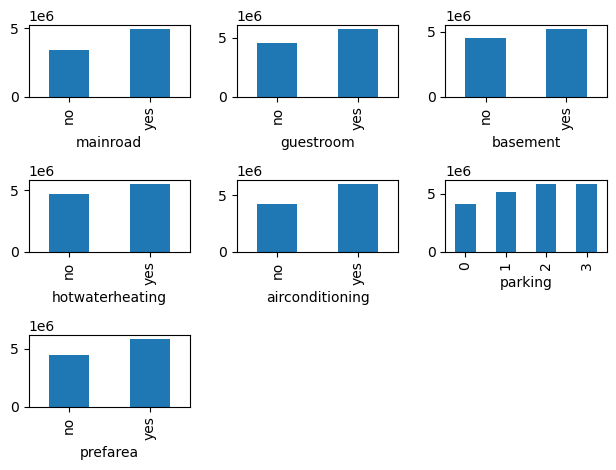

In [137]:
plt.subplot(3,3,1)
df.groupby('mainroad')['price'].mean().plot(kind='bar')
plt.subplot(3,3,2)
df.groupby('guestroom')['price'].mean().plot(kind='bar')
plt.subplot(3,3,3)
df.groupby('basement')['price'].mean().plot(kind='bar')
plt.subplot(3,3,4)
df.groupby('hotwaterheating')['price'].mean().plot(kind='bar')
plt.subplot(3,3,5)
df.groupby('airconditioning')['price'].mean().plot(kind='bar')
plt.subplot(3,3,6)
df.groupby('parking')['price'].mean().plot(kind='bar')
plt.subplot(3,3,7)
df.groupby('prefarea')['price'].mean().plot(kind='bar')
plt.tight_layout()

Text(0.5, 1.0, 'area kde')

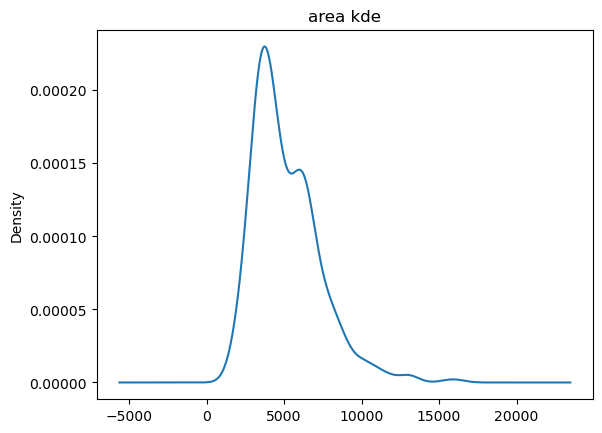

In [138]:
df['area'].plot(kind='kde')
plt.title("area kde")

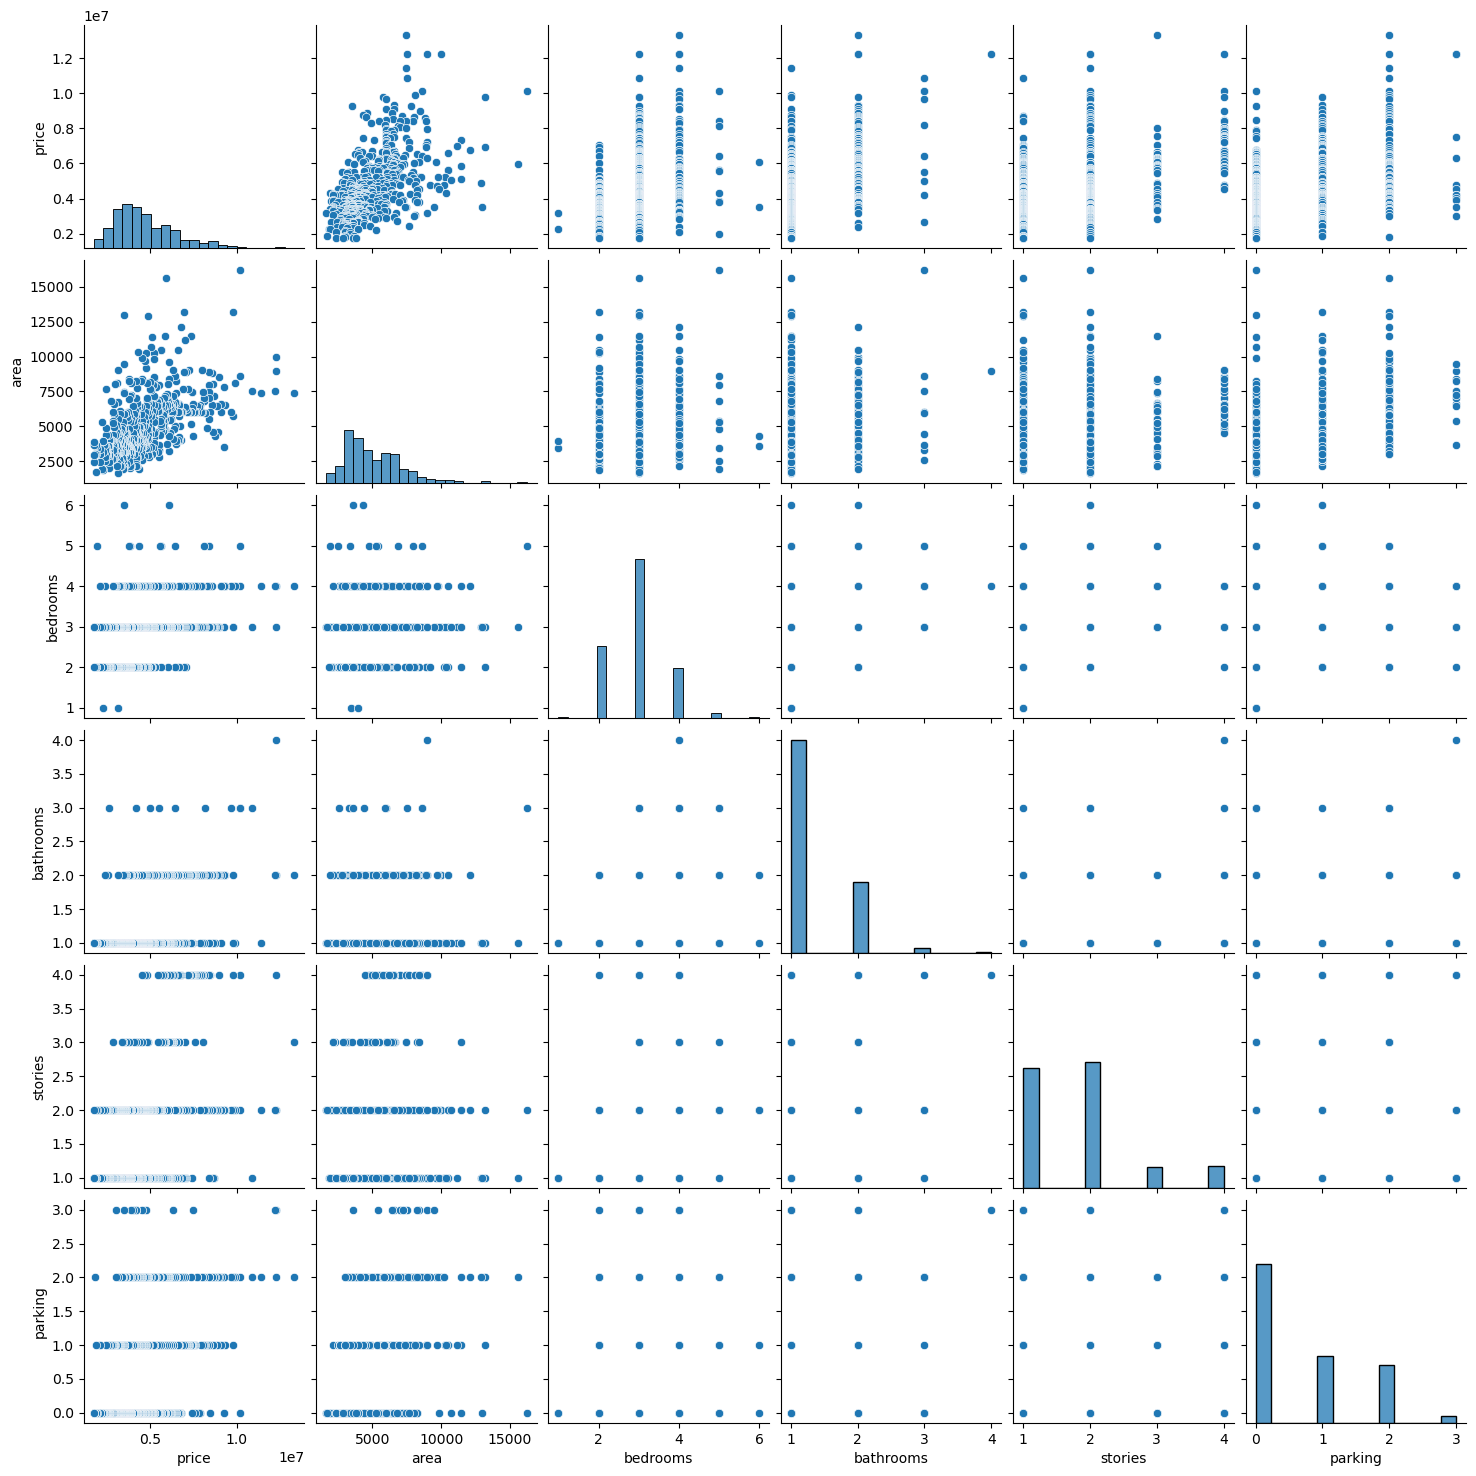

In [139]:
sns.pairplot(df)

no need to remove the outlairs

## **Splitting the data**

### **Splitting into x and y**

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [141]:
y=df['price']

In [142]:
df.drop('price',axis=1)

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [145]:
df['Mainroad']=df.mainroad.map({'yes':1,'no':0})
df['Guestroom']=df.guestroom.map({'yes':1,'no':0})
df['Basement']=df.basement.map({'yes':1,'no':0})
df['Hotwaterheating']=df.hotwaterheating.map({'yes':1,'no':0})
df['Airconditioning']=df.airconditioning.map({'yes':1,'no':0})
df['Prefarea']=df.prefarea.map({'yes':1,'no':0})
df['furnish']=df.furnishingstatus.map({'furnished':2,'semi-furnished':1,'unfurnished':0})
df=df.drop(['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus'],axis=1)

In [146]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'Mainroad', 'Guestroom', 'Basement', 'Hotwaterheating',
       'Airconditioning', 'Prefarea', 'furnish'],
      dtype='object')

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   parking          545 non-null    int64
 6   Mainroad         545 non-null    int64
 7   Guestroom        545 non-null    int64
 8   Basement         545 non-null    int64
 9   Hotwaterheating  545 non-null    int64
 10  Airconditioning  545 non-null    int64
 11  Prefarea         545 non-null    int64
 12  furnish          545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


In [148]:
x=df.drop('price',axis=1)

In [152]:
x,y.shape

(     area  bedrooms  bathrooms  stories  parking  Mainroad  Guestroom  \
 0    7420         4          2        3        2         1          0   
 1    8960         4          4        4        3         1          0   
 2    9960         3          2        2        2         1          0   
 3    7500         4          2        2        3         1          0   
 4    7420         4          1        2        2         1          1   
 ..    ...       ...        ...      ...      ...       ...        ...   
 540  3000         2          1        1        2         1          0   
 541  2400         3          1        1        0         0          0   
 542  3620         2          1        1        0         1          0   
 543  2910         3          1        1        0         0          0   
 544  3850         3          1        2        0         1          0   
 
      Basement  Hotwaterheating  Airconditioning  Prefarea  furnish  
 0           0                0         

### **Splitting data into test train**

In [153]:
from sklearn.model_selection import train_test_split

In [154]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [155]:
x_train,x_test.shape

(     area  bedrooms  bathrooms  stories  parking  Mainroad  Guestroom  \
 271  1905         5          1        2        0         0          0   
 355  8250         3          1        1        2         1          0   
 151  4400         4          1        2        2         1          0   
 29   5500         4          2        2        1         1          0   
 534  3000         4          1        2        0         1          0   
 ..    ...       ...        ...      ...      ...       ...        ...   
 70   4000         3          2        2        0         1          0   
 132  5200         3          1        3        0         1          0   
 289  5850         2          1        1        2         1          1   
 109  6615         4          2        2        1         1          1   
 480  3480         3          1        2        1         0          0   
 
      Basement  Hotwaterheating  Airconditioning  Prefarea  furnish  
 271         1                0         

## **Model: Linear Regressor**

In [156]:
from sklearn.linear_model import LinearRegression

In [157]:
lr=LinearRegression()

In [158]:
lr.fit(x_train,y_train)

LinearRegression()

## **Predicting data**

In [160]:
y_pred=lr.predict(x_test)

## **Model Evaluation**

In [161]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [163]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [168]:
print(f'mean absolute error: {mae}, mean squared error: {mse}, r2 score: {r2}')

mean absolute error: 731365.8227168074, mean squared error: 807848838640.2025, r2 score: 0.7624579467323477


### **Data Visualization**

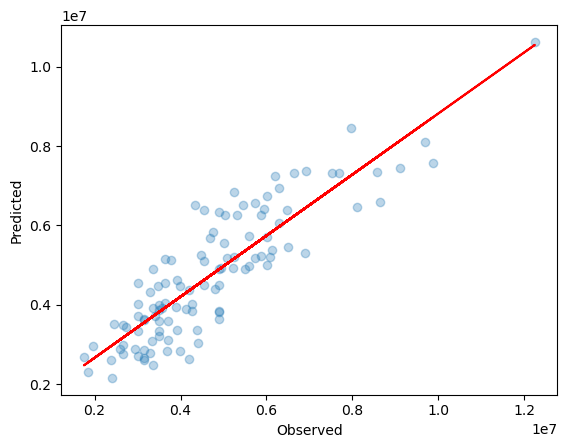

In [169]:
plt.scatter(x=y_test, y=y_pred,alpha=0.3)
plt.xlabel('Observed')
plt.ylabel('Predicted')
z=np.polyfit(y_test,y_pred,1)
p=np.poly1d(z)
plt.plot(y_test,p(y_test),'Red')

## **Testing**

In [170]:
x.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'Mainroad',
       'Guestroom', 'Basement', 'Hotwaterheating', 'Airconditioning',
       'Prefarea', 'furnish'],
      dtype='object')

In [178]:
area=int(input("Enter area of the house: "))
bedrooms=int(input("Enter number of bedrooms: "))
bathrooms=int(input("Enter number of bathrooms: "))
stories=int(input("Enter number of stories: "))
mainroad=int(input("Is the house on main road (1 for yes, 0 for no): "))
guestroom=int(input("Is there a guest room (1 for yes, 0 for no): "))
basement=int(input("Is there a basement (1 for yes, 0 for no): "))
hotwaterheating=int(input("Is there hot water heating (1 for yes, 0 for no: "))
airconditioning=int(input("Is there air conditioning (1 for yes, 0 for no): "))
parking=int(input("Enter number of parking spaces: "))
prefarea=int(input("Is the house in preferred area (1 for yes, 0 for no): "))
furnish=int(input("Enter furnishing status (2 for furnished, 1 for semi-furnished, 0 for unfurnished): "))

In [180]:
data=[area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnish]
price=lr.predict([data])[0]
print(f"for the house which have this features is predicted to have a price of ${price:.2f}")

for the house which have this features is predicted to have a price of $9152900.16


/opt/anaconda3/envs/tf2.18/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## **Save the model**

In [181]:
import pickle as pkl

In [182]:
pkl.dump(lr,open('housing_model.pkl','wb'))